# Zadaća — Dio 2: EDA na vlastitom datasetu 🐈
### Kućne mačke u Engleskoj

Dataset ima **101 kućnu mačku**. Za svaku mačku vlasnik je upisao spol, starost, da li je sterilisana, koliko sati dnevno provodi u kući, koliko mačaka živi u kući, čime se hrani i **koliko plijena mjesečno donese kući**.

Izvor: [TidyTuesday — Pet Cats UK](https://github.com/rfordatascience/tidytuesday/tree/master/data/2023/2023-01-31)

**struktura → kvalitet podataka → jedna varijabla → dvije varijable → grupe/segmenti → zaključak**

## Korak 0 — Učitavanje podataka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2023/2023-01-31/cats_uk_reference.csv"
df = pd.read_csv(URL)


In [2]:
# prikaži prvih 5 redova
df.head()

,tag_id,animal_id,animal_taxon,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Tommy-Tag,Tommy,Felis catus,2017-06-03T01:02:09Z,2017-06-10T02:10:52Z,True,12.5,Neutered,m,12.5,2,True,True,False,UK,11.0
1,Athena,Athena,Felis catus,2017-06-24T01:02:13Z,2017-06-30T23:59:32Z,True,3.0,Spayed,f,7.5,2,True,True,False,UK,3.0
2,Ares,Ares,Felis catus,2017-06-24T01:03:57Z,2017-06-30T23:58:01Z,NaN,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Lola,Lola,Felis catus,2017-06-24T01:18:49Z,2017-06-30T09:04:40Z,True,3.0,Spayed,f,17.5,1,True,True,False,UK,10.0
4,Maverick,Maverick,Felis catus,2017-06-25T01:04:35Z,2017-07-03T09:10:07Z,True,3.0,Neutered,m,12.5,1,True,True,True,UK,7.0


## Korak 1 — Struktura dataset-a
Koliko redova/kolona imamo, koji su tipovi podataka i koliko toga nedostaje?

In [3]:
# oblik dataset-a (broj redova, broj kolona)
print("Broj redova i kolona:", df.shape)

# tipovi podataka i broj ne-null vrijednosti po koloni
df.info()

Broj redova i kolona: (101, 16)
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tag_id                         101 non-null    str    
 1   animal_id                      101 non-null    str    
 2   animal_taxon                   101 non-null    str    
 3   deploy_on_date                 101 non-null    str    
 4   deploy_off_date                101 non-null    str    
 5   hunt                           92 non-null     object 
 6   prey_p_month                   101 non-null    float64
 7   animal_reproductive_condition  98 non-null     str    
 8   animal_sex                     101 non-null    str    
 9   hrs_indoors                    101 non-null    float64
 10  n_cats                         101 non-null    int64  
 11  food_dry                       101 non-null    bool   
 12  food_wet                     

In [4]:
# deskriptivna statistika za sve kolone
df.describe(include='all')

,tag_id,animal_id,animal_taxon,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
count,101,101,101,101,101,92,101.000000,98,101,101.000000,101.000000,101,101,91,101,100.000000
unique,101,101,1,100,101,2,NaN,3,2,NaN,NaN,2,2,2,1,NaN
top,Tommy-Tag,Tommy,Felis catus,2017-10-23T01:03:54Z,2017-06-10T02:10:52Z,True,NaN,Neutered,m,NaN,NaN,True,True,False,UK,NaN
freq,1,1,101,2,1,81,NaN,55,57,NaN,NaN,97,71,49,101,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,3.742574,NaN,NaN,11.856436,2.079208,NaN,NaN,NaN,NaN,5.420000
std,NaN,NaN,NaN,NaN,NaN,NaN,4.831467,NaN,NaN,5.227971,0.996827,NaN,NaN,NaN,NaN,3.384994
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,2.500000,1.000000,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN,NaN,7.500000,1.000000,NaN,NaN,NaN,NaN,3.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,12.500000,2.000000,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,17.500000,3.000000,NaN,NaN,NaN,NaN,8.000000


## Korak 2 — Kvalitet podataka (čišćenje)

### 2a — Koliko nedostaje po koloni?

In [5]:
df.isnull().sum()

tag_id                            0
animal_id                         0
animal_taxon                      0
deploy_on_date                    0
deploy_off_date                   0
hunt                              9
prey_p_month                      0
animal_reproductive_condition     3
animal_sex                        0
hrs_indoors                       0
n_cats                            0
food_dry                          0
food_wet                          0
food_other                       10
study_site                        0
age_years                         1
dtype: int64

### 2b — Nedostaje `hunt` (da li mačka lovi)
Za 9 mačaka ne znamo da li love. Ali znamo koliko plijena donose (`prey_p_month`). Ako mačka donosi 0 plijena, zaključujemo da ne lovi.

In [6]:
# pogledajmo mačke kojima nedostaje 'hunt'
df[df['hunt'].isna()][['animal_id', 'hunt', 'prey_p_month']]

,animal_id,hunt,prey_p_month
2,Ares,NaN,0.0
21,Wilfred,NaN,0.0
46,Lightening Bugg,NaN,0.0
57,Jezebel,NaN,0.0
63,Tipsy,NaN,0.0
80,Maggie,NaN,0.0
81,Lily,NaN,0.0
84,Pants,NaN,0.0
88,Neil,NaN,0.0


In [7]:
# sve donose 0 plijena -> upisujemo False
df.loc[df['hunt'].isna() & (df['prey_p_month'] == 0), 'hunt'] = False
df['hunt'].value_counts()

hunt
True     81
False    20
Name: count, dtype: int64

### 2c — Ista stvar pod dva imena (sterilizacija)
`Neutered` (mužjak) i `Spayed` (ženka) znače isto: mačka je sterilisana. Pravimo jednu kolonu sa vrijednostima `da` / `ne`.

In [8]:
print(df['animal_reproductive_condition'].value_counts(dropna=False))

df['sterilisana'] = df['animal_reproductive_condition'].replace({
    'Neutered': 'da',
    'Spayed': 'da',
    'Not fixed': 'ne'
})
df['sterilisana'].value_counts(dropna=False)

animal_reproductive_condition
Neutered     55
Spayed       41
NaN           3
Not fixed     2
Name: count, dtype: int64


sterilisana
da     96
NaN     3
ne      2
Name: count, dtype: int64

### 2d — Nazivi na našem jeziku
Spol je upisan kao `m` / `f`. Sate u kući pretvaramo u grupe jer su to odgovori iz upitnika (npr. `2.5` znači "0-5 sati").

In [9]:
df['spol'] = df['animal_sex'].replace({'m': 'mužjak', 'f': 'ženka'})

df['u_kuci'] = df['hrs_indoors'].replace({
    2.5: '0-5 h',
    7.5: '5-10 h',
    12.5: '10-15 h',
    17.5: '15-20 h',
    22.5: '20-24 h'
})
df[['animal_id', 'spol', 'hrs_indoors', 'u_kuci']].head()

,animal_id,spol,hrs_indoors,u_kuci
0,Tommy,mužjak,12.5,10-15 h
1,Athena,ženka,7.5,5-10 h
2,Ares,mužjak,7.5,5-10 h
3,Lola,ženka,17.5,15-20 h
4,Maverick,mužjak,12.5,10-15 h


### 2e — Duplikati

In [10]:
# da li se neka mačka pojavljuje dvaput?
print("Broj dupliranih mačaka:", df['animal_id'].duplicated().sum())

Broj dupliranih mačaka: 0


## Korak 3 — Prvi grafovi

### 3a — Koliko su mačke stare? (histogram)

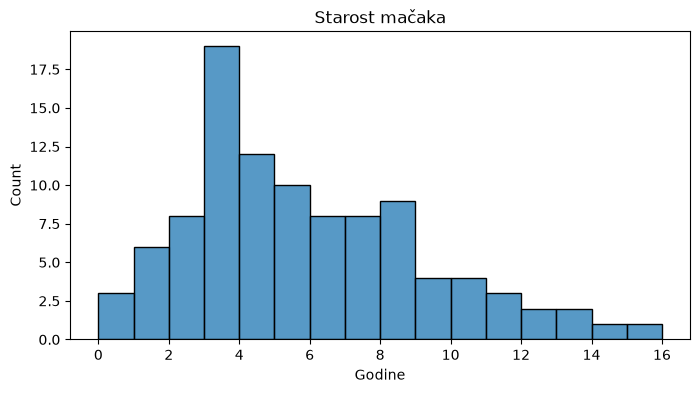

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df['age_years'], bins=16)
plt.title('Starost mačaka')
plt.xlabel('Godine')
plt.show()

### 3b — Da li mužjaci love više od ženki? (boxplot)

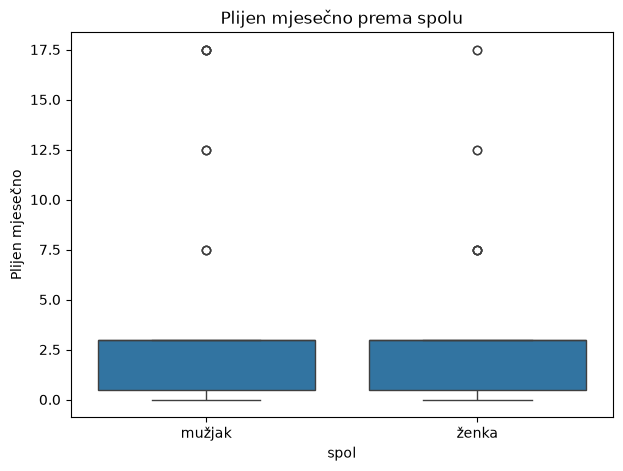

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='spol', y='prey_p_month')
plt.title('Plijen mjesečno prema spolu')
plt.ylabel('Plijen mjesečno')
plt.show()

## Korak 4 — Filtriranje i sortiranje
### 4a — 10 najvećih lovaca

In [13]:
df.sort_values('prey_p_month', ascending=False)[
    ['animal_id', 'spol', 'age_years', 'u_kuci', 'prey_p_month']
].head(10)

,animal_id,spol,age_years,u_kuci,prey_p_month
45,Maxwell,mužjak,6.0,5-10 h,17.5
7,Jago,mužjak,2.0,5-10 h,17.5
40,Sid,ženka,4.0,5-10 h,17.5
48,Carrots,mužjak,3.0,5-10 h,17.5
87,Macaulay Mccat,ženka,6.0,0-5 h,17.5
62,Spot,mužjak,2.0,5-10 h,17.5
94,Ginge,mužjak,3.0,0-5 h,17.5
0,Tommy,mužjak,11.0,10-15 h,12.5
27,Tom,ženka,3.0,10-15 h,12.5
95,Jasper,mužjak,2.0,5-10 h,12.5


### 4b — Prosječan plijen po grupama (groupby)

In [14]:
df.groupby('spol')['prey_p_month'].mean().round(1)

spol
mužjak    3.8
ženka     3.7
Name: prey_p_month, dtype: float64

In [15]:
df.groupby('u_kuci')['prey_p_month'].mean().sort_values(ascending=False).round(1)

u_kuci
0-5 h      6.8
5-10 h     5.3
10-15 h    3.7
15-20 h    1.2
20-24 h    0.9
Name: prey_p_month, dtype: float64

## Izazov — Šta utiče na to koliko mačka lovi?

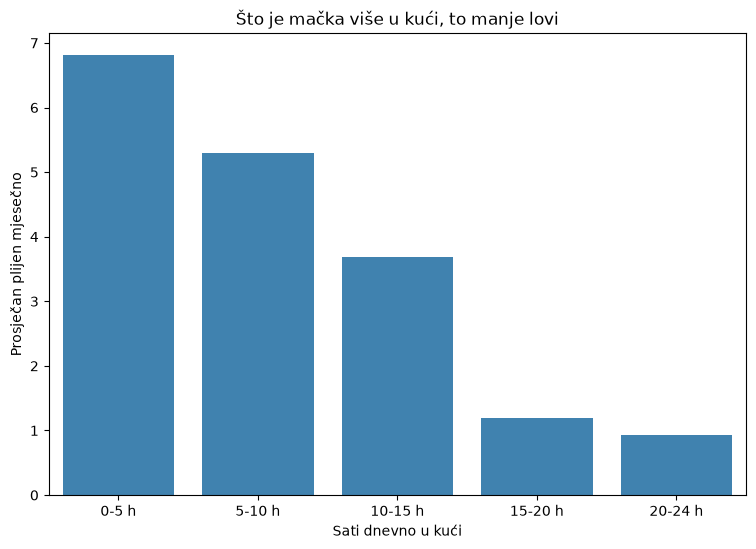

In [16]:
redoslijed = ['0-5 h', '5-10 h', '10-15 h', '15-20 h', '20-24 h']

plt.figure(figsize=(9, 6))
sns.barplot(data=df, x='u_kuci', y='prey_p_month', order=redoslijed, errorbar=None, color='#2e86c1')
plt.xlabel('Sati dnevno u kući')
plt.ylabel('Prosječan plijen mjesečno')
plt.title('Što je mačka više u kući, to manje lovi')  # naslov = poenta!
plt.show()

**Zaključak:** spol ne utiče na lov, jer mužjaci i ženke donose podjednako plijena (oko 3,7 mjesečno). Ono što zaista utiče je **koliko je mačka napolju**. Mačke koje su skoro cijeli dan napolju donesu oko **7 plijena mjesečno**, a mačke koje su skoro stalno u kući manje od 1. To je **7 puta manje**. Ako vlasnik želi zaštititi ptice i miševe u komšiluku, najviše pomaže da mačka provodi više vremena u kući.